In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"D:\kaggle_Dataset\E-commerce Customer Behavior - Sheet1.csv")
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [5]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [6]:
df.fillna("Unknown" , inplace = True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'membership_type',
       'total_spend', 'items_purchased', 'average_rating', 'discount_applied',
       'days_since_last_purchase', 'satisfaction_level'],
      dtype='object')

In [9]:
df['customer_value'] = df['total_spend'] / df['items_purchased']

In [33]:
def segment(x):
    if x >= 1000:
        return "High"
    elif x >= 500:
        return "Medium"
    else:
        return "Low"

df['customer_segment'] = df['total_spend'].apply(segment)

In [34]:
def recency(x):
    if x <= 20:
        return "High"     # very recent → good
    elif x <= 50:
        return "Medium"
    else:
        return "Low"      # long time → risky

df['recency_score'] = df['days_since_last_purchase'].apply(recency)

In [35]:
df.to_csv("cleaned_ecommerce_data.csv", index = False)

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cleaned_ecommerce_data.csv")

In [24]:
# high value customers
df.sort_values(by = 'total_spend',ascending = False).head(10)

,customer_id,gender,age,city,membership_type,total_spend,items_purchased,average_rating,discount_applied,days_since_last_purchase,satisfaction_level,customer_value,customer_segment,recency_score
9,110,Male,28,San Francisco,Gold,1520.1,21,4.8,False,9,Satisfied,72.385714,High,High
117,218,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
87,188,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
159,260,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
189,290,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
57,158,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
230,331,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
27,128,Male,28,San Francisco,Gold,1500.1,21,4.9,False,10,Satisfied,71.433333,High,High
45,146,Male,28,San Francisco,Gold,1490.1,21,4.9,False,9,Satisfied,70.957143,High,High
105,206,Male,28,San Francisco,Gold,1490.1,21,4.9,False,9,Satisfied,70.957143,High,High


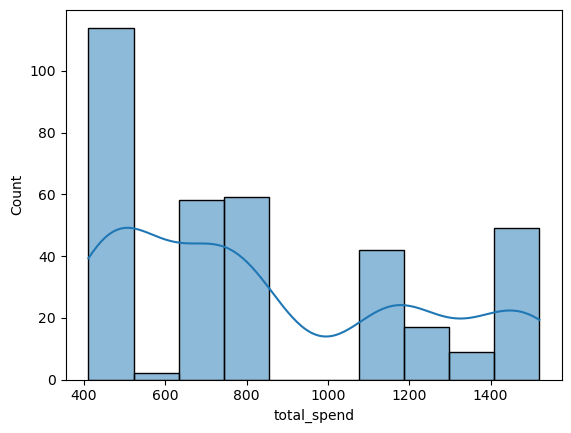

In [25]:
# Distribution analysis
sns.histplot(df['total_spend'],kde = True)
plt.show()

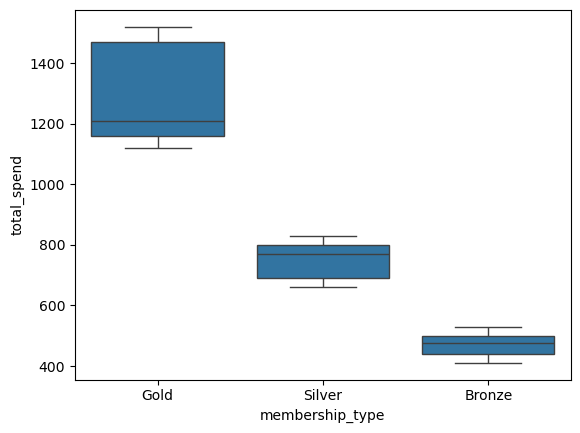

In [26]:
# membership impact
sns.boxplot(x='membership_type', y='total_spend', data=df)
plt.show()

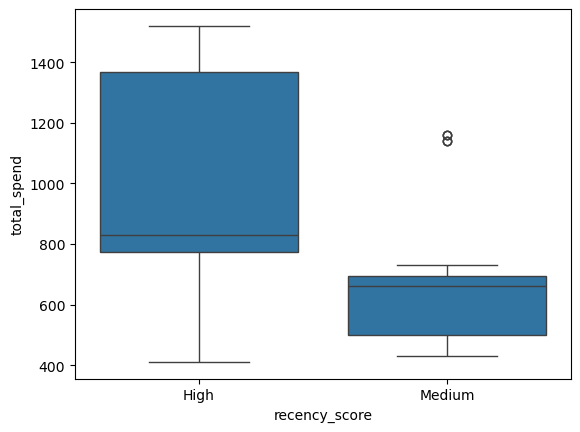

In [27]:
# Customer Behaviour(Recency vs spend)
sns.boxplot(x='recency_score', y='total_spend', data=df)
plt.show()

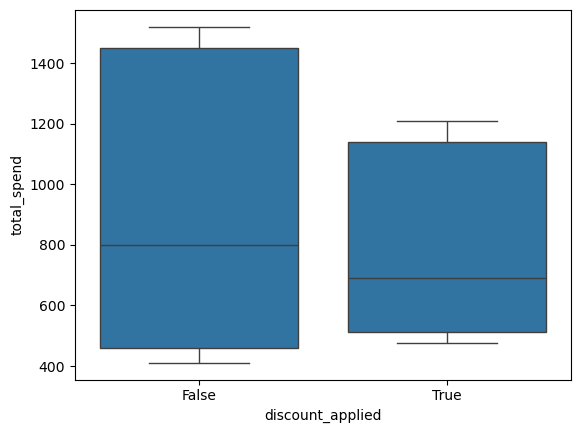

In [28]:
# Discount strategy
sns.boxplot(x='discount_applied', y='total_spend', data=df)
plt.show()

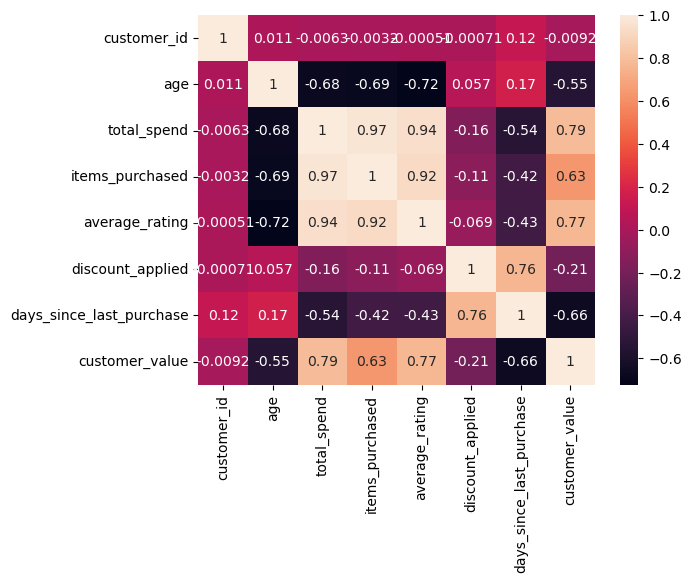

In [29]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr,annot=True)
plt.show()

In [30]:
def segment(x):
    if x >= 1000:
        return "High"
    elif x >= 500:
        return "Medium"
    else:
        return "Low"

df['customer_segment'] = df['total_spend'].apply(segment)